<a href="https://colab.research.google.com/github/OleSpooky/README/blob/main/vacuum_gap_diagnostics_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Single Run Summary:
  gap_width: 3.1214
  gap_depth: 0.9500
  curvature: 19.8709
  global_corr: -0.0757


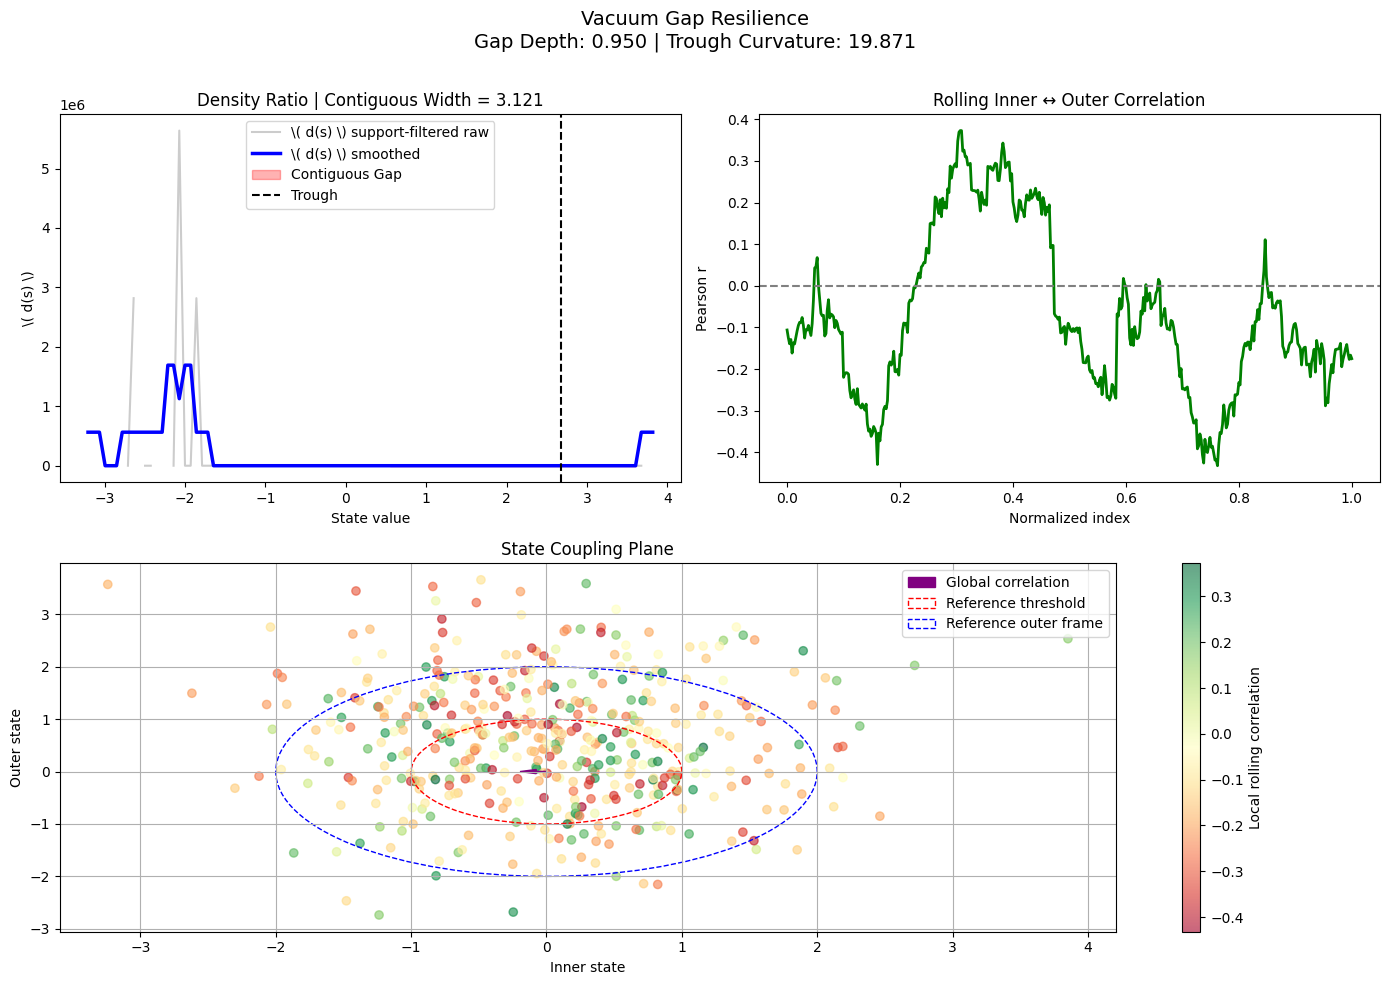

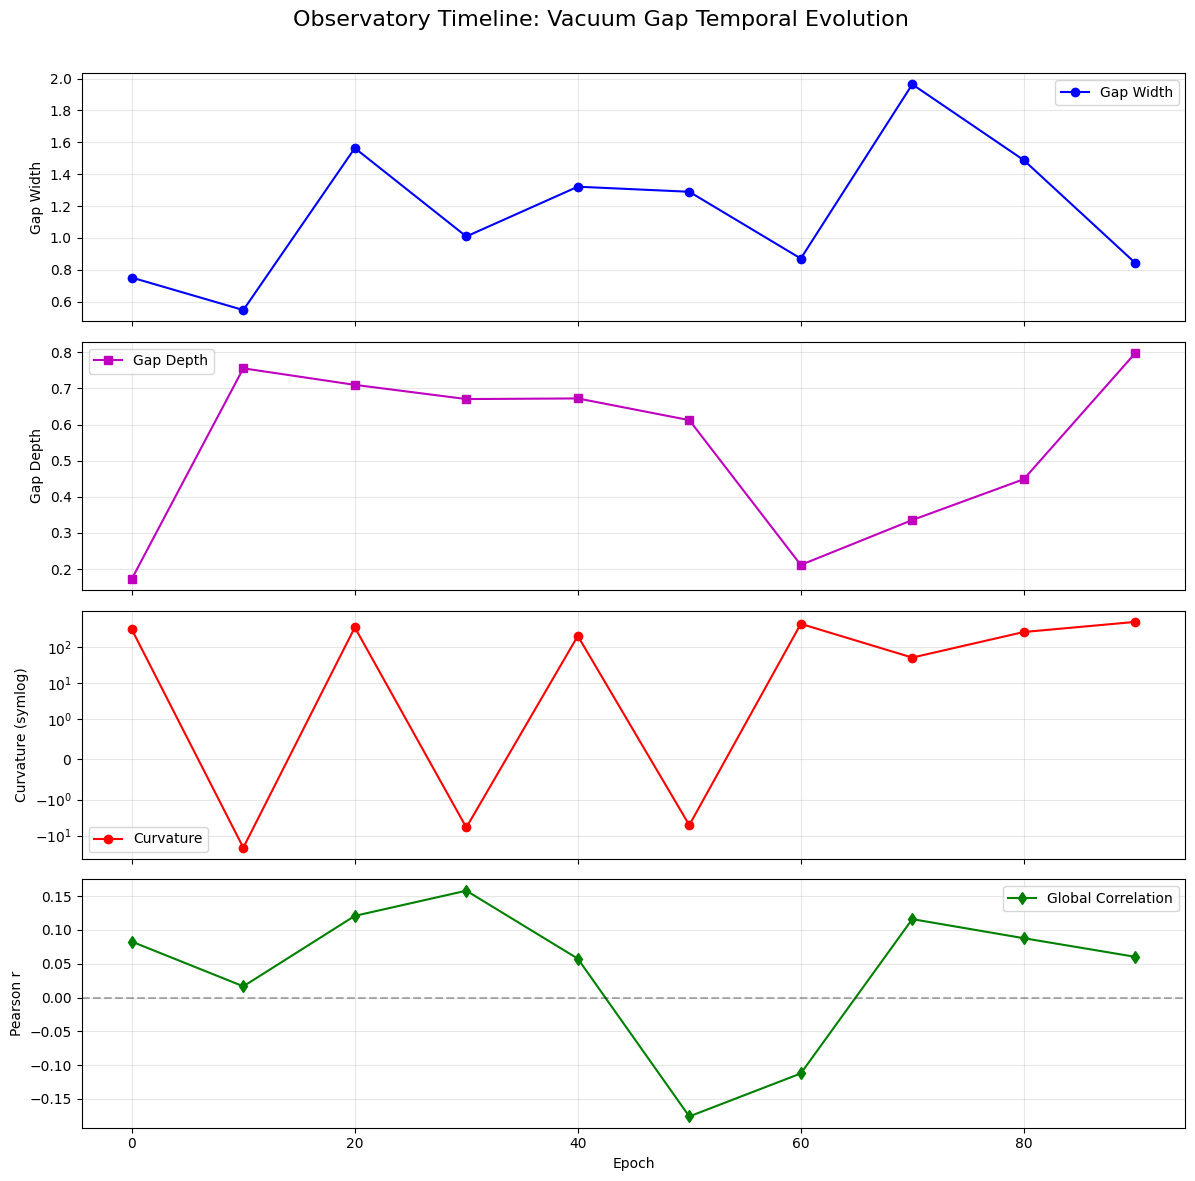


Timeline DataFrame:
       gap_width  gap_depth   curvature  global_corr
epoch                                               
0       0.751224   0.173197  300.036637     0.082590
10      0.547379   0.755349  -21.415794     0.016519
20      1.563591   0.709678  342.747813     0.120691
30      1.009175   0.670378   -5.936834     0.157927
40      1.321389   0.672108  198.775056     0.057431


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
from typing import Dict, Optional, Tuple
from matplotlib.patches import Circle

@dataclass
class VacuumGapMetrics:
    """Stable result schema for a single gap analysis."""
    gap_width: float          # Contiguous insulation width
    gap_depth: float          # Average depth of the gap (1 - d(s))
    curvature: float          # Error-quenching gradient at trough
    global_corr: float        # Overall inner ↔ outer Pearson r
    rolling_corr: np.ndarray  # Time-resolved correlation trace

    def summary(self) -> Dict[str, float]:
        return {
            "gap_width": self.gap_width,
            "gap_depth": self.gap_depth,
            "curvature": self.curvature,
            "global_corr": self.global_corr,
        }

def contiguous_gap_width(mask: np.ndarray, ds: float) -> float:
    """Calculates the widest continuous region where the condition is met."""
    best = run = 0
    for flag in mask:
        run = run + 1 if flag else 0
        best = max(best, run)
    return best * ds

def analyze_vacuum_gap(
    inner_state: np.ndarray,
    outer_state: np.ndarray,
    *,
    bins: int = 100,
    window: int = 50,
    smooth_window: int = 5,
    support_threshold: float = 0.02,
    plot: bool = True,
    title: str = "Vacuum Gap Resilience",
) -> Tuple[VacuumGapMetrics, Optional[plt.Figure]]:
    """
    Core kernel: computes Vacuum Gap observables and optional diagnostic plot.
    """
    inner_state = np.asarray(inner_state, dtype=float)
    outer_state = np.asarray(outer_state, dtype=float)

    if len(inner_state) != len(outer_state):
        raise ValueError("inner_state and outer_state must have the same length")
    if window < 2:
        raise ValueError("window must be >= 2 for rolling correlation")
    if smooth_window < 1:
        raise ValueError("smooth_window must be >= 1")

    # === Histogram over state values ===
    value_min = min(inner_state.min(), outer_state.min())
    value_max = max(inner_state.max(), outer_state.max())
    hist_i, edges = np.histogram(inner_state, bins=bins, density=True, range=(value_min, value_max))
    hist_o, _ = np.histogram(outer_state, bins=edges, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ds = centers[1] - centers[0]

    # === Support mask to suppress tail hallucinations ===
    support_mask = (hist_i + hist_o) > support_threshold
    d = np.full_like(hist_i, np.nan, dtype=float)
    d[support_mask] = hist_i[support_mask] / (hist_o[support_mask] + 1e-8)

    # === Fill and smooth for unified geometry ===
    d_fill = np.where(np.isfinite(d), d, 1.0)
    smooth_window = max(1, min(smooth_window, len(hist_i)))
    if smooth_window % 2 == 0:
        smooth_window += 1
    d_smooth = np.convolve(d_fill, np.ones(smooth_window) / smooth_window, mode="same")

    # === Extract Observables ===
    gap_mask = d_smooth < 1.0
    gap_width = contiguous_gap_width(gap_mask, ds)

    min_idx = int(np.argmin(d_smooth))
    gap_depth = max(0.0, 1.0 - d_smooth[min_idx])

    curvature = (
        (d_smooth[min_idx + 1] - 2 * d_smooth[min_idx] + d_smooth[min_idx - 1]) / ds**2
        if 0 < min_idx < len(d_smooth) - 1
        else np.nan
    )

    # === Rolling correlation (NaN-safe) ===
    roll_corr = []
    for i in range(len(inner_state) - window + 1):
        a, b = inner_state[i : i + window], outer_state[i : i + window]
        if np.std(a) < 1e-8 or np.std(b) < 1e-8:
            roll_corr.append(np.nan)
        else:
            roll_corr.append(np.corrcoef(a, b)[0, 1])
    roll_corr = np.array(roll_corr)

    global_corr = float(np.corrcoef(inner_state, outer_state)[0, 1])

    # === Build metrics ===
    metrics = VacuumGapMetrics(
        gap_width=gap_width,
        gap_depth=gap_depth,
        curvature=curvature,
        global_corr=global_corr,
        rolling_corr=roll_corr,
    )

    # === Plot (optional) ===
    fig = None
    if plot:
        fig = plt.figure(figsize=(14, 10))
        gs = fig.add_gridspec(2, 2)

        ax1 = fig.add_subplot(gs[0, 0])
        ax1.plot(centers, d, lw=1.5, alpha=0.4, color="gray", label=r"\( d(s) \) support-filtered raw")
        ax1.plot(centers, d_smooth, lw=2.5, color="blue", label=r"\( d(s) \) smoothed")
        ax1.fill_between(centers, 0, 1, where=gap_mask, color="red", alpha=0.3, label="Contiguous Gap")
        ax1.axvline(centers[min_idx], color="k", linestyle="--", label="Trough")
        ax1.set_title(f"Density Ratio | Contiguous Width = {gap_width:.3f}")
        ax1.set_xlabel("State value")
        ax1.set_ylabel(r"\( d(s) \)")
        ax1.legend()

        ax2 = fig.add_subplot(gs[0, 1])
        ax2.plot(np.linspace(0, 1, len(roll_corr)), roll_corr, color="green", lw=2)
        ax2.axhline(0, color="gray", linestyle="--")
        ax2.set_title("Rolling Inner ↔ Outer Correlation")
        ax2.set_xlabel("Normalized index")
        ax2.set_ylabel("Pearson r")

        ax3 = fig.add_subplot(gs[1, :])
        if len(roll_corr) > 0:
            cent_idx = np.arange(window // 2, window // 2 + len(roll_corr))
            sc = ax3.scatter(
                inner_state[cent_idx],
                outer_state[cent_idx],
                c=np.nan_to_num(roll_corr, nan=0.0),
                cmap="RdYlGn",
                alpha=0.6,
            )
            fig.colorbar(sc, ax=ax3, label="Local rolling correlation")

        ax3.arrow(0, 0, global_corr, 0, head_width=0.08, color="purple", label="Global correlation")
        ax3.add_patch(Circle((0, 0), radius=1, fill=False, linestyle="--", color="red", label="Reference threshold"))
        ax3.add_patch(Circle((0, 0), radius=2, fill=False, linestyle="--", color="blue", label="Reference outer frame"))
        ax3.set_xlabel("Inner state")
        ax3.set_ylabel("Outer state")
        ax3.set_title("State Coupling Plane")
        ax3.grid(True)
        ax3.legend()

        plt.suptitle(title + f"\nGap Depth: {gap_depth:.3f} | Trough Curvature: {curvature:.3f}", fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.97])

    return metrics, fig

def batch_analyze_epochs(
    inner_epochs: Dict[int, np.ndarray],
    outer_epochs: Dict[int, np.ndarray],
    **kwargs,
) -> Dict[int, VacuumGapMetrics]:
    """Batch analysis across multiple epochs with explicit key alignment."""
    common_epochs = sorted(set(inner_epochs.keys()) & set(outer_epochs.keys()))
    return {
        epoch: analyze_vacuum_gap(
            inner_epochs[epoch],
            outer_epochs[epoch],
            plot=False,
            **kwargs
        )[0]
        for epoch in common_epochs
    }

def plot_observatory_timeline(timeline: Dict[int, VacuumGapMetrics]) -> plt.Figure:
    """Atlas view of gap evolution over epochs (4-panel diagnostic)."""
    epochs = sorted(list(timeline.keys()))
    widths = [timeline[e].gap_width for e in epochs]
    depths = [timeline[e].gap_depth for e in epochs]
    curvatures = [timeline[e].curvature for e in epochs]
    corrs = [timeline[e].global_corr for e in epochs]

    fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
    axs[0].plot(epochs, widths, "b-o", label="Gap Width")
    axs[0].set_ylabel("Gap Width")
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()

    axs[1].plot(epochs, depths, "m-s", label="Gap Depth")
    axs[1].set_ylabel("Gap Depth")
    axs[1].grid(True, alpha=0.3)
    axs[1].legend()

    axs[2].plot(epochs, curvatures, "r-o", label="Curvature")
    axs[2].set_yscale('symlog', linthresh=1.0)
    axs[2].set_ylabel("Curvature (symlog)")
    axs[2].grid(True, alpha=0.3)
    axs[2].legend()

    axs[3].plot(epochs, corrs, "g-d", label="Global Correlation")
    axs[3].set_xlabel("Epoch")
    axs[3].set_ylabel("Pearson r")
    axs[3].axhline(0, color="k", linestyle="--", alpha=0.3)
    axs[3].grid(True, alpha=0.3)
    axs[3].legend()

    plt.suptitle("Observatory Timeline: Vacuum Gap Temporal Evolution", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    return fig

def timeline_to_dataframe(timeline: Dict[int, VacuumGapMetrics]) -> pd.DataFrame:
    """Export timeline to DataFrame sorted by epoch."""
    epochs = sorted(list(timeline.keys()))
    data = [timeline[e].summary() for e in epochs]
    df = pd.DataFrame(data, index=epochs)
    df.index.name = "epoch"
    return df

def make_textbook_vacuum_gap_example():
    """Generates a deterministic synthetic test to verify the instrument."""
    np.random.seed(42)
    inner = np.random.normal(0, 1, 500)
    outer = np.random.normal(0.5, 1.2, 500)
    return inner, outer

if __name__ == "__main__":
    # === Single-run snapshot test ===
    inner_test, outer_test = make_textbook_vacuum_gap_example()
    metrics_test, fig_test = analyze_vacuum_gap(inner_test, outer_test, plot=True)

    print("Single Run Summary:")
    for key, val in metrics_test.summary().items():
        print(f"  {key}: {val:.4f}")

    if fig_test:
        plt.show()

    # === Mock observatory timeline ===
    mock_timeline = {
        ep: VacuumGapMetrics(
            gap_width=np.random.uniform(0.5, 2.0),
            gap_depth=np.random.uniform(0.1, 0.8),
            curvature=np.random.uniform(-50, 500),
            global_corr=np.random.uniform(-0.2, 0.2),
            rolling_corr=np.array([]),
        )
        for ep in range(0, 100, 10)
    }

    obs_fig = plot_observatory_timeline(mock_timeline)
    plt.show()

    df_out = timeline_to_dataframe(mock_timeline)
    print("\nTimeline DataFrame:")
    print(df_out.head())